# TWO-STAGE HSI PIPELINE (Camera CSV -> Plastic? -> PET?)
First the training and at the end I have a testing part only.

## Training and testing

In [ ]:
# ============================================================
# TWO-STAGE HSI PIPELINE (Camera CSV -> Plastic? -> PET?)
# Tailored for:
#   - Camera-exported CSV spectra in:  C:\Users\camil\Documents\2025_02\MDB2\data\Mylab
#   - Virgin plastics dataset in:      C:\Users\camil\Documents\2025_02\MDB2\data\Full_Data\hyperspectral_database\virgin plastics
#
# Pipeline:
#   Spectrum
#     ↓
#   [Stage 1] Plastic vs Non-Plastic   (trained from Virgin Plastics dataset)
#     ↓
#   [Stage 2] PET vs Other Plastics    (trained from Virgin Plastics dataset)
#
# Notes:
# - This script supports MATLAB v7.3 .mat files (HDF5) using h5py.
# - It trains ONCE and saves artifacts. After that, you can just run inference.
# - For camera CSV, it supports x0000/y0000 style OR wavelength/intensity columns.
# - IMPORTANT: If your camera export already applied SNV, set CSV_APPLY_NORM=None
#   (do not SNV twice).
# ============================================================

# -----------------------------
# CELL 1 — Imports + Paths
# -----------------------------
import os
from pathlib import Path
import pickle
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import h5py

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.svm import SVC

from scipy.interpolate import interp1d

# -------- Your paths --------
MYLAB_DIR = Path(r"C:\Users\camil\Documents\2025_02\MDB2\data\Mylab")
VIRGIN_ROOT = Path(r"C:\Users\camil\Documents\2025_02\MDB2\data\Full_Data\hyperspectral_database\virgin plastics")

# -------- Output artifacts --------
OUTPUT_DIR = Path(r"C:\Users\camil\Documents\2025_02\MDB2\models_virgin_pipeline")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SCALER_PATH = OUTPUT_DIR / "scaler.pkl"
STAGE1_MODEL_PATH = OUTPUT_DIR / "stage1_plastic_vs_nonplastic.pkl"
STAGE2_MODEL_PATH = OUTPUT_DIR / "stage2_pet_vs_otherplastics.pkl"
COMMON_WAVELENGTHS_PATH = OUTPUT_DIR / "common_wavelengths.npy"

# -------- Camera wavelength assumptions (fallback) --------
# If your CSV does NOT include real wavelengths, we assume linear spacing.
CAM_WL_MIN = 430.0
CAM_WL_MAX = 1000.0

# -------- Common grid used by models --------
COMMON_WAVELENGTH_POINTS = 330  # keep consistent with your earlier design
COMMON_WAVELENGTH_MIN = 430.0
COMMON_WAVELENGTH_MAX = 1000.0

# -------- CSV export preprocessing --------
# If your camera software already applied SNV, set to None here.
# Options: None, "snv", "max", "l2"
CSV_APPLY_NORM = None

# -------- Training sampling (Virgin dataset is huge) --------
MAX_SAMPLES_TOTAL = 200_000   # total rows used for training (after filtering)
RANDOM_STATE = 42

# -------- Stage thresholds --------
STAGE1_PLASTIC_THRESHOLD = 0.50
STAGE2_PET_THRESHOLD = 0.50


# -----------------------------
# CELL 2 — Helpers: interpolation + normalization
# -----------------------------
def build_common_wavelengths() -> np.ndarray:
    return np.linspace(COMMON_WAVELENGTH_MIN, COMMON_WAVELENGTH_MAX, COMMON_WAVELENGTH_POINTS).astype(np.float32)

def interpolate_spectra(
    spectra: np.ndarray,
    wavelengths_src: np.ndarray,
    wavelengths_common: np.ndarray,
) -> np.ndarray:
    """
    spectra: (N, Bsrc)
    wavelengths_src: (Bsrc,)
    wavelengths_common: (Bcommon,)
    """
    wavelengths_src = np.asarray(wavelengths_src, dtype=np.float32).ravel()
    wavelengths_common = np.asarray(wavelengths_common, dtype=np.float32).ravel()

    # sort by wavelength
    order = np.argsort(wavelengths_src)
    w_src = wavelengths_src[order]
    X = spectra[:, order]

    f = interp1d(
        w_src,
        X,
        axis=1,
        bounds_error=False,
        fill_value="extrapolate",
    )
    return f(wavelengths_common).astype(np.float32)

def apply_norm_1d(y: np.ndarray, mode: Optional[str]) -> np.ndarray:
    y = np.asarray(y, dtype=np.float32).ravel()
    if mode is None:
        return y
    if mode == "snv":
        return (y - y.mean()) / (y.std() + 1e-12)
    if mode == "max":
        return y / (np.max(y) + 1e-12)
    if mode == "l2":
        return y / (np.linalg.norm(y) + 1e-12)
    raise ValueError("mode must be None, 'snv', 'max', or 'l2'")


# -----------------------------
# CELL 3 — Camera CSV Loader (smart)
# -----------------------------
def load_camera_csv_smart(
    csv_path: str,
    which: int = 0,
    fallback_wl_min: float = CAM_WL_MIN,
    fallback_wl_max: float = CAM_WL_MAX,
    apply_norm: Optional[str] = CSV_APPLY_NORM,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Supports:
      A) columns: x0000,y0000,x0001,y0001,...
      B) columns: wavelength-like + one spectrum column
    Returns:
      spectrum (B,), wavelengths (B,)
    """
    df = pd.read_csv(csv_path)

    x_name = f"x{which:04d}"
    y_name = f"y{which:04d}"

    if x_name in df.columns and y_name in df.columns:
        y = df[y_name].to_numpy(dtype=np.float32)
        # x is typically band index → assume linear wavelength
        wls = np.linspace(fallback_wl_min, fallback_wl_max, len(y), dtype=np.float32)
    else:
        # try find wavelength column
        wl_candidates = [c for c in df.columns if ("wave" in c.lower() or "wl" in c.lower() or "nm" in c.lower())]
        if not wl_candidates:
            raise ValueError(
                f"Could not detect x/y columns or wavelength column in CSV.\nColumns: {df.columns.tolist()}"
            )
        wl_col = wl_candidates[0]

        # choose first other numeric column as spectrum
        other_cols = [c for c in df.columns if c != wl_col]
        if not other_cols:
            raise ValueError("CSV has wavelength column but no spectrum column.")
        y_col = other_cols[0]

        wls = df[wl_col].to_numpy(dtype=np.float32)
        y = df[y_col].to_numpy(dtype=np.float32)

    y = apply_norm_1d(y, apply_norm)
    return y, wls


# -----------------------------
# CELL 4 — Virgin Plastics Loader (HDF5 / MATLAB v7.3)
# -----------------------------
# These paths match your colleague's working approach.
DATA_PATH = ['data', 'data', 'prop', 'data'] 
LABEL_CODE_PATH = ['data', 'data', 'prop', 'class', 'data', 'code'] 
NAMES_PATH = ['data', 'data', 'prop', 'class', 'data', 'list', 'names']
SIZES_PATH = ['data', 'data', 'prop', 'class', 'data', 'sizes']

# Band range used by colleague (index slice). Adjust if needed.
RANGE_START = 35
RANGE_END = 169

def get_h5(f: h5py.File, path_list: List[str]) -> np.ndarray:
    cur = f
    for k in path_list:
        cur = cur[k]
    return np.array(cur[()])

def decode_char_matrix(raw_matrix: np.ndarray) -> np.ndarray:
    raw = np.array(raw_matrix)
    if raw.ndim != 2:
        return raw.astype(str)

    mat = raw if raw.shape[0] > raw.shape[1] else raw.T
    out = []
    for row in mat:
        s = "".join(chr(int(c)) for c in row if int(c) > 0).strip()
        out.append(s)
    return np.array(out, dtype=object)

def map_codes_to_names(y_codes: np.ndarray, class_names: np.ndarray, class_sizes: np.ndarray) -> np.ndarray:
    """
    Handles both:
      - 1..K indexing (MATLAB 1-based)
      - negative / arbitrary codes via frequency matching with sizes
    """
    y_codes = np.asarray(y_codes).flatten()

    # Case A: direct 1..K
    if y_codes.min() >= 1 and y_codes.max() <= len(class_names):
        idx = y_codes.astype(int) - 1
        return class_names[idx]

    # Case B: frequency matching
    unique_codes, actual_counts = np.unique(y_codes, return_counts=True)
    code_count_map = dict(zip(unique_codes, actual_counts))

    code_to_name = {}
    used = set()

    for i, name in enumerate(class_names):
        expected = int(class_sizes[i]) if i < len(class_sizes) else None
        found = False
        if expected is not None:
            for code, cnt in code_count_map.items():
                if cnt == expected and code not in used:
                    code_to_name[code] = name
                    used.add(code)
                    found = True
                    break
        if not found:
            if i < len(unique_codes) and unique_codes[i] not in used:
                code_to_name[unique_codes[i]] = name
                used.add(unique_codes[i])

    return np.array([code_to_name.get(c, "Unknown") for c in y_codes], dtype=object)

def categorize_label(lbl: str) -> str:
    """
    Categories for Stage 1 & Stage 2.
    Adjust rules here if your dataset uses different naming.
    """
    s = str(lbl).strip().upper()

    # Non-plastic classes
    if "WATER" in s:
        return "WATER"
    if "ORGANIC" in s:
        return "ORGANIC"

    # Plastics
    if "PET" in s:
        return "PET"
    if "PVC" in s:
        return "PVC"
    if "PS" in s:
        return "PS"
    if "PP" in s:
        return "PP"
    if "PC" in s:
        return "PC"
    if "PE" in s or "HDPE" in s or "LDPE" in s:
        return "PE"

    return "OTHER"

def find_virgin_mat_files(root: Path) -> List[Path]:
    mats = sorted(list(root.rglob("*.mat")))
    return mats

def load_virgin_dataset(file_path: Path) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
      X: (N, B) float32
      y_cat: (N,) object categories (PET/PE/PP/.../WATER/ORGANIC/OTHER)
      y_raw: (N,) raw class name strings
    """
    with h5py.File(file_path, "r") as f:
        X = get_h5(f, DATA_PATH)
        if X.shape[0] < X.shape[1]:
            X = X.T  # ensure (samples, bands)
        y_codes = get_h5(f, LABEL_CODE_PATH).flatten()

        class_names = decode_char_matrix(get_h5(f, NAMES_PATH))
        class_sizes = get_h5(f, SIZES_PATH).flatten()

    y_raw = map_codes_to_names(y_codes, class_names, class_sizes)
    y_cat = np.array([categorize_label(x) for x in y_raw], dtype=object)

    # band slice (like colleague)
    X = X[:, RANGE_START:RANGE_END].astype(np.float32)

    return X, y_cat, y_raw


# -----------------------------
# CELL 5 — Build Stage 1 + Stage 2 datasets (with sampling)
# -----------------------------
def build_stage_datasets(X: np.ndarray, y_cat: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Stage 1: plastic vs non-plastic
      plastic = {PET, PE, PP, PS, PVC, PC}
      non-plastic = {WATER, ORGANIC}
    Stage 2: PET vs other plastics (only within plastic)
      PET = 1, other plastics = 0
    """
    plastic_set = {"PET", "PE", "PP", "PS", "PVC", "PC"}
    non_plastic_set = {"WATER", "ORGANIC"}

    # Stage 1
    m1 = np.isin(y_cat, list(plastic_set | non_plastic_set))
    X1 = X[m1]
    y1 = np.array([1 if c in plastic_set else 0 for c in y_cat[m1]], dtype=np.int64)

    # Stage 2 (plastics only)
    m2 = np.isin(y_cat, list(plastic_set))
    X2 = X[m2]
    y2 = np.array([1 if c == "PET" else 0 for c in y_cat[m2]], dtype=np.int64)

    return X1, y1, X2, y2

def subsample(X: np.ndarray, y: np.ndarray, n_max: int, seed: int = RANDOM_STATE) -> Tuple[np.ndarray, np.ndarray]:
    if X.shape[0] <= n_max:
        return X, y
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=n_max, replace=False)
    return X[idx], y[idx]


# -----------------------------
# CELL 6 — Train + Save Artifacts
# -----------------------------
def train_and_save_from_virgin():
    mats = find_virgin_mat_files(VIRGIN_ROOT)
    if not mats:
        raise FileNotFoundError(f"No .mat files found under: {VIRGIN_ROOT}")

    # pick first file by default (change if you want a specific one)
    file_path = mats[0]
    print("Using virgin dataset file:", file_path)

    X, y_cat, y_raw = load_virgin_dataset(file_path)
    print("Loaded X:", X.shape)
    print("Category counts:\n", pd.Series(y_cat).value_counts().head(20))

    X1, y1, X2, y2 = build_stage_datasets(X, y_cat)
    print("\nStage 1 dataset:", X1.shape, "classes:", np.unique(y1, return_counts=True))
    print("Stage 2 dataset:", X2.shape, "classes:", np.unique(y2, return_counts=True))

    # sample to keep training manageable
    X1, y1 = subsample(X1, y1, MAX_SAMPLES_TOTAL)
    X2, y2 = subsample(X2, y2, MAX_SAMPLES_TOTAL)

    # common wavelength grid for the *model*
    w_common = build_common_wavelengths()
    np.save(COMMON_WAVELENGTHS_PATH, w_common)

    # IMPORTANT:
    # Virgin dataset X is band-index-based slice (RANGE_START:RANGE_END) with no explicit wavelengths here.
    # We map band index linearly to [COMMON_WAVELENGTH_MIN, COMMON_WAVELENGTH_MAX] as an approximation.
    # If the virgin dataset provides real wavelengths somewhere, we should swap this with the true axis.
    B_src = X1.shape[1]
    w_src = np.linspace(COMMON_WAVELENGTH_MIN, COMMON_WAVELENGTH_MAX, B_src, dtype=np.float32)

    X1_common = interpolate_spectra(X1, w_src, w_common)
    X2_common = interpolate_spectra(X2, w_src, w_common)

    # fit scaler on all training spectra used
    scaler = StandardScaler()
    scaler.fit(np.vstack([X1_common, X2_common]))

    X1s = scaler.transform(X1_common)
    X2s = scaler.transform(X2_common)

    # Train Stage 1
    X1_tr, X1_te, y1_tr, y1_te = train_test_split(
        X1s, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1
    )
    stage1 = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)
    stage1.fit(X1_tr, y1_tr)
    pred1 = stage1.predict(X1_te)
    print("\n=== Stage 1 report (Plastic=1 vs Non-plastic=0) ===")
    print(classification_report(y1_te, pred1, digits=3))

    # Train Stage 2
    X2_tr, X2_te, y2_tr, y2_te = train_test_split(
        X2s, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2
    )
    stage2 = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)
    stage2.fit(X2_tr, y2_tr)
    pred2 = stage2.predict(X2_te)
    print("\n=== Stage 2 report (PET=1 vs Other plastics=0) ===")
    print(classification_report(y2_te, pred2, digits=3))

    # Save artifacts
    with open(SCALER_PATH, "wb") as f:
        pickle.dump(scaler, f)
    with open(STAGE1_MODEL_PATH, "wb") as f:
        pickle.dump(stage1, f)
    with open(STAGE2_MODEL_PATH, "wb") as f:
        pickle.dump(stage2, f)

    print("\nSaved artifacts to:", OUTPUT_DIR)

def artifacts_status():
    paths = {
        "scaler.pkl": SCALER_PATH,
        "stage1.pkl": STAGE1_MODEL_PATH,
        "stage2.pkl": STAGE2_MODEL_PATH,
        "common_wavelengths.npy": COMMON_WAVELENGTHS_PATH,
    }
    print("\n=== ARTIFACT STATUS ===")
    ok = True
    for k, p in paths.items():
        exists = p.exists()
        size = p.stat().st_size if exists else None
        print(f"{k:22s} exists={exists}  size={size}")
        if not exists or (size == 0):
            ok = False
    return ok


# -----------------------------
# CELL 7 — Load Artifacts + Inference Functions
# -----------------------------
def load_artifacts():
    with open(SCALER_PATH, "rb") as f:
        scaler = pickle.load(f)
    with open(STAGE1_MODEL_PATH, "rb") as f:
        stage1 = pickle.load(f)
    with open(STAGE2_MODEL_PATH, "rb") as f:
        stage2 = pickle.load(f)
    w_common = np.load(COMMON_WAVELENGTHS_PATH).astype(np.float32)
    return scaler, stage1, stage2, w_common

def preprocess_single_spectrum_for_model(
    spectrum_raw: np.ndarray,
    wavelengths_raw: np.ndarray,
    scaler: StandardScaler,
    w_common: np.ndarray,
) -> np.ndarray:
    """
    1) interpolate raw spectrum to model common grid
    2) scale using saved scaler
    """
    spectrum_raw = np.asarray(spectrum_raw, dtype=np.float32).ravel()
    wavelengths_raw = np.asarray(wavelengths_raw, dtype=np.float32).ravel()

    X_common = interpolate_spectra(spectrum_raw[np.newaxis, :], wavelengths_raw, w_common)
    X_scaled = scaler.transform(X_common)
    return X_scaled

def predict_two_stage(
    spectrum_raw: np.ndarray,
    wavelengths_raw: np.ndarray,
    stage1_threshold: float = STAGE1_PLASTIC_THRESHOLD,
    stage2_threshold: float = STAGE2_PET_THRESHOLD,
) -> Tuple[str, float, Optional[float]]:
    """
    Returns:
      label: "NOT PLASTIC" | "PLASTIC_NOT_PET" | "PLASTIC_PET"
      p_plastic: float
      p_pet: float or None (if Stage 1 says non-plastic)
    """
    scaler, stage1, stage2, w_common = load_artifacts()
    x = preprocess_single_spectrum_for_model(spectrum_raw, wavelengths_raw, scaler, w_common)

    p_plastic = float(stage1.predict_proba(x)[0, 1])
    if p_plastic < stage1_threshold:
        return "NOT PLASTIC", p_plastic, None

    p_pet = float(stage2.predict_proba(x)[0, 1])
    if p_pet >= stage2_threshold:
        return "PLASTIC_PET", p_plastic, p_pet
    else:
        return "PLASTIC_NOT_PET", p_plastic, p_pet


# -----------------------------
# CELL 8 — TRAIN ONCE (if needed)
# -----------------------------
ok = artifacts_status()
if not ok:
    print("\nArtifacts missing or invalid -> training now...")
    train_and_save_from_virgin()
else:
    print("\n✅ Artifacts look OK. Skipping training.")


# -----------------------------
# CELL 9 — TEST: Run inference on ALL CSVs in MYLAB_DIR
# -----------------------------
csv_files = sorted(list(MYLAB_DIR.glob("*.csv")))
print("\nFound CSVs in Mylab:", len(csv_files))
for p in csv_files:
    print(" -", p.name)

def test_csv_file(csv_path: Path, which_list=(0, 1)):
    print(f"\n=== Testing: {csv_path.name} ===")
    for which in which_list:
        try:
            spec, wls = load_camera_csv_smart(str(csv_path), which=which)
        except Exception as e:
            print(f"  curve which={which}: could not load ({e})")
            continue

        label, p_plastic, p_pet = predict_two_stage(spec, wls)
        print(f"  curve which={which}:")
        print(f"    label      : {label}")
        print(f"    P(plastic) : {p_plastic:.6f}")
        print(f"    P(PET)     : {p_pet if p_pet is not None else 'SKIPPED'}")

for csv_path in csv_files:
    test_csv_file(csv_path, which_list=(0, 1))


# -----------------------------
# OPTIONAL: If you want to test one specific file
# -----------------------------
# csv_path = MYLAB_DIR / "Blue_lego.csv"
# spec, wls = load_camera_csv_smart(str(csv_path), which=0)
# print(predict_two_stage(spec, wls))



=== ARTIFACT STATUS ===
scaler.pkl             exists=False  size=None
stage1.pkl             exists=False  size=None
stage2.pkl             exists=False  size=None
common_wavelengths.npy exists=True  size=1448

Artifacts missing or invalid -> training now...
Using virgin dataset file: C:\Users\camil\Documents\2025_02\MDB2\data\Full_Data\hyperspectral_database\virgin plastics\level1_data_visnir\data_vis.mat
Loaded X: (1380798, 134)
Category counts:
 PE         396534
PP         263137
WATER      261889
PET        144860
ORGANIC    138649
OTHER       92775
PS          82954
Name: count, dtype: int64

Stage 1 dataset: (1288023, 134) classes: (array([0, 1]), array([400538, 887485]))
Stage 2 dataset: (887485, 134) classes: (array([0, 1]), array([742625, 144860]))

=== Stage 1 report (Plastic=1 vs Non-plastic=0) ===
              precision    recall  f1-score   support

           0      0.896     0.991     0.941     12336
           1      0.996     0.949     0.972     27664

    accuracy

## Graphs

### A) Plot the camera spectra (Black vs Blue, both curves)

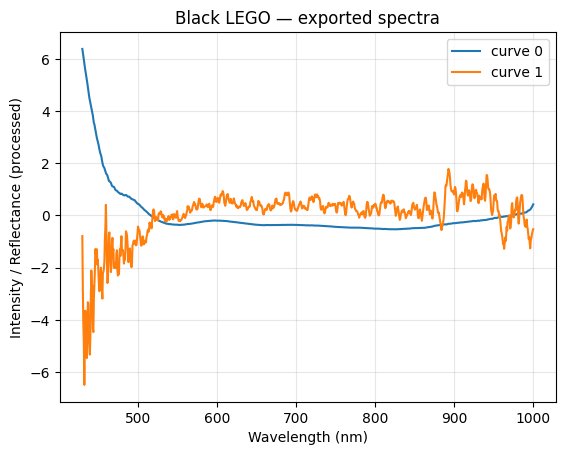

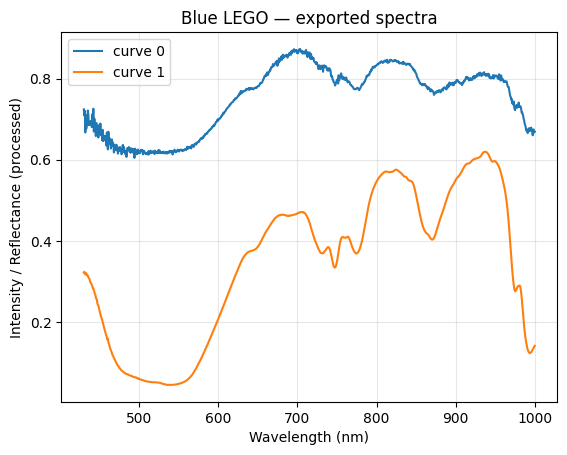

In [2]:
import matplotlib.pyplot as plt
import numpy as np

black = MYLAB_DIR / "Black_lego.csv"
blue  = MYLAB_DIR / "Blue_lego.csv"

def plot_two_curves(path, title):
    plt.figure()
    for which in (0, 1):
        y, w = load_camera_csv_smart(str(path), which=which)
        plt.plot(w, y, label=f"curve {which}")
    plt.title(title)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity / Reflectance (processed)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_two_curves(black, "Black LEGO — exported spectra")
plot_two_curves(blue,  "Blue LEGO — exported spectra")


### B) Bar chart of predicted probabilities

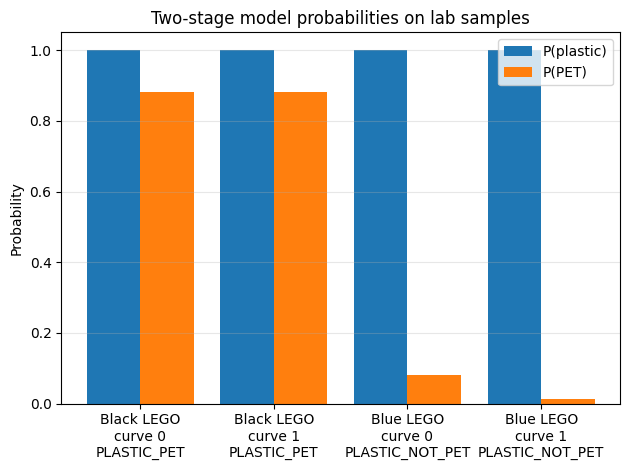

In [ ]:
import matplotlib.pyplot as plt

items = [
    ("Black LEGO",  black, 0),
    ("Black LEGO",  black, 1),
    ("Blue LEGO",   blue,  0),
    ("Blue LEGO",   blue,  1),
]

labels = []
p_plastics = []
p_pets = []

for name, path, which in items:
    spec, wls = load_camera_csv_smart(str(path), which=which)
    pred, p_plastic, p_pet = predict_two_stage(spec, wls)
    labels.append(f"{name}\ncurve {which}\n{pred}")
    p_plastics.append(p_plastic)
    p_pets.append(0.0 if p_pet is None else p_pet)

x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, p_plastics, width=0.4, label="P(plastic)")
plt.bar(x + 0.2, p_pets,     width=0.4, label="P(PET)")
plt.xticks(x, labels, rotation=0)
plt.ylim(0, 1.05)
plt.ylabel("Probability")
plt.title("Two-stage model probabilities on lab samples")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### C) “Decision threshold” visualization (shows why label flips)

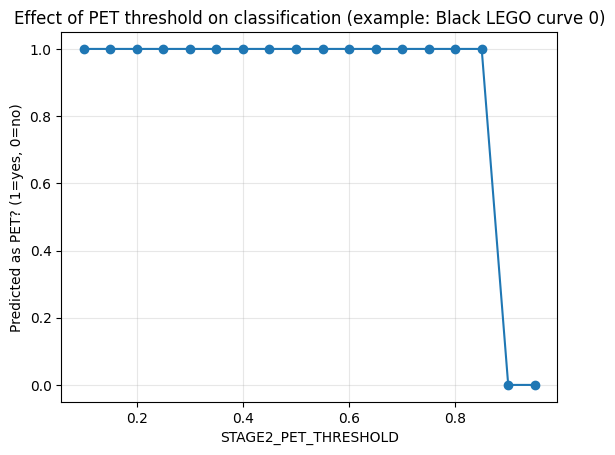

For this sample: P(plastic)= 0.9999999999999699 P(PET)= 0.8805194292926768


In [4]:
import matplotlib.pyplot as plt

pet_thresholds = np.linspace(0.1, 0.95, 18)

def pet_label_from_threshold(p_pet, thr):
    return "PET" if p_pet >= thr else "NOT PET"

# Example: Black curve 0
spec, wls = load_camera_csv_smart(str(black), which=0)
_, p_plastic, p_pet = predict_two_stage(spec, wls)

plt.figure()
plt.plot(pet_thresholds, [1 if pet_label_from_threshold(p_pet, t)=="PET" else 0 for t in pet_thresholds], marker="o")
plt.title("Effect of PET threshold on classification (example: Black LEGO curve 0)")
plt.xlabel("STAGE2_PET_THRESHOLD")
plt.ylabel("Predicted as PET? (1=yes, 0=no)")
plt.grid(True, alpha=0.3)
plt.show()

print("For this sample: P(plastic)=", p_plastic, "P(PET)=", p_pet)


## Just testing

In [1]:
# ============================================================
# TEST-ONLY: Load saved pipeline + run inference on Mylab CSVs
# (kernel can be cleared; no training done here)
# ============================================================

import os
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

# -----------------------
# PATHS
# -----------------------
MYLAB_DIR   = Path(r"C:\Users\camil\Documents\2025_02\MDB2\data\Mylab\New")
MODEL_DIR   = Path(r"C:\Users\camil\Documents\2025_02\MDB2\models_virgin_pipeline")

SCALER_PATH = MODEL_DIR / "scaler.pkl"
S1_PATH     = MODEL_DIR / "stage1_plastic_vs_nonplastic.pkl"
S2_PATH     = MODEL_DIR / "stage2_pet_vs_otherplastics.pkl"
WLS_PATH    = MODEL_DIR / "common_wavelengths.npy"

# -----------------------
# SETTINGS (change here)
# -----------------------
STAGE1_PLASTIC_THRESHOLD = 0.50
STAGE2_PET_THRESHOLD     = 0.50

# If CSV has no wavelength column, assume linear spacing:
CAM_WL_MIN = 430.0
CAM_WL_MAX = 1000.0

# If camera export already applied SNV: keep None
CSV_APPLY_NORM = None   # None | "snv" | "max" | "l2"


# -----------------------
# HELPERS
# -----------------------
def interpolate_spectra(spectra, wavelengths_src, wavelengths_common):
    wavelengths_src = np.asarray(wavelengths_src, dtype=np.float32).ravel()
    wavelengths_common = np.asarray(wavelengths_common, dtype=np.float32).ravel()

    order = np.argsort(wavelengths_src)
    w_src = wavelengths_src[order]
    X = spectra[:, order]

    f = interp1d(w_src, X, axis=1, bounds_error=False, fill_value="extrapolate")
    return f(wavelengths_common).astype(np.float32)

def apply_norm_1d(y, mode):
    y = np.asarray(y, dtype=np.float32).ravel()
    if mode is None:
        return y
    if mode == "snv":
        return (y - y.mean()) / (y.std() + 1e-12)
    if mode == "max":
        return y / (np.max(y) + 1e-12)
    if mode == "l2":
        return y / (np.linalg.norm(y) + 1e-12)
    raise ValueError("mode must be None, 'snv', 'max', or 'l2'")

def load_camera_csv_smart(csv_path, which=0):
    df = pd.read_csv(csv_path)

    x_name = f"x{which:04d}"
    y_name = f"y{which:04d}"

    # Format A: x0000/y0000 style
    if x_name in df.columns and y_name in df.columns:
        y = df[y_name].to_numpy(dtype=np.float32)
        wls = np.linspace(CAM_WL_MIN, CAM_WL_MAX, len(y), dtype=np.float32)
        y = apply_norm_1d(y, CSV_APPLY_NORM)
        return y, wls

    # Format B: wavelength-like column
    wl_candidates = [c for c in df.columns if ("wave" in c.lower() or "wl" in c.lower() or "nm" in c.lower())]
    if not wl_candidates:
        raise ValueError(f"CSV format not recognized. Columns: {df.columns.tolist()}")

    wl_col = wl_candidates[0]
    other_cols = [c for c in df.columns if c != wl_col]
    y_col = other_cols[0]

    wls = df[wl_col].to_numpy(dtype=np.float32)
    y = df[y_col].to_numpy(dtype=np.float32)
    y = apply_norm_1d(y, CSV_APPLY_NORM)
    return y, wls

def load_artifacts():
    for p in [SCALER_PATH, S1_PATH, S2_PATH, WLS_PATH]:
        if not p.exists() or p.stat().st_size == 0:
            raise FileNotFoundError(f"Missing/corrupt artifact: {p}")

    with open(SCALER_PATH, "rb") as f:
        scaler = pickle.load(f)
    with open(S1_PATH, "rb") as f:
        stage1 = pickle.load(f)
    with open(S2_PATH, "rb") as f:
        stage2 = pickle.load(f)
    w_common = np.load(WLS_PATH).astype(np.float32)
    return scaler, stage1, stage2, w_common

def predict_two_stage(spectrum_raw, wavelengths_raw):
    scaler, stage1, stage2, w_common = load_artifacts()

    X_common = interpolate_spectra(spectrum_raw[np.newaxis, :], wavelengths_raw, w_common)
    X_scaled = scaler.transform(X_common)

    p_plastic = float(stage1.predict_proba(X_scaled)[0, 1])
    if p_plastic < STAGE1_PLASTIC_THRESHOLD:
        return "NOT_PLASTIC", p_plastic, None

    p_pet = float(stage2.predict_proba(X_scaled)[0, 1])
    if p_pet >= STAGE2_PET_THRESHOLD:
        return "PLASTIC_PET", p_plastic, p_pet
    return "PLASTIC_NOT_PET", p_plastic, p_pet


# -----------------------
# RUN TESTS ON ALL CSVs
# -----------------------
print("Testing CSVs in:", MYLAB_DIR)
csv_files = sorted(MYLAB_DIR.glob("*.csv"))
print("Found:", [p.name for p in csv_files])

for csv_path in csv_files:
    print(f"\n=== {csv_path.name} ===")
    for which in (0, 1):
        try:
            spec, wls = load_camera_csv_smart(str(csv_path), which=which)
            label, p_plastic, p_pet = predict_two_stage(spec, wls)
            print(f"  curve {which}: {label} | P(plastic)={p_plastic:.4f} | P(PET)={p_pet if p_pet is not None else 'SKIPPED'}")
        except Exception as e:
            print(f"  curve {which}: ERROR -> {e}")


Testing CSVs in: C:\Users\camil\Documents\2025_02\MDB2\data\Mylab\New
Found: ['PETG.csv']

=== PETG.csv ===
  curve 0: PLASTIC_PET | P(plastic)=1.0000 | P(PET)=0.8816648187459815
  curve 1: PLASTIC_PET | P(plastic)=1.0000 | P(PET)=0.8773275244427803


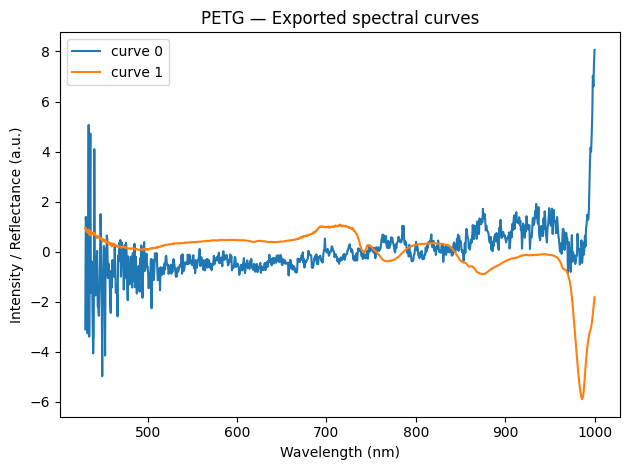

In [2]:
import matplotlib.pyplot as plt

def plot_spectrum(csv_path: Path, which_list=(0,1), title_prefix=""):
    plt.figure()
    for which in which_list:
        spec, wls = load_camera_csv_smart(str(csv_path), which=which)
        plt.plot(wls, spec, label=f"curve {which}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity / Reflectance (a.u.)")
    plt.title(f"{title_prefix}{csv_path.stem} — Exported spectral curves")
    plt.legend()
    plt.tight_layout()
    plt.show()

for csv_path in csv_files:
    plot_spectrum(csv_path, which_list=(0,1))


   file  curve        label  p_plastic     p_pet
0  PETG      0  PLASTIC_PET        1.0  0.881665
1  PETG      1  PLASTIC_PET        1.0  0.877328


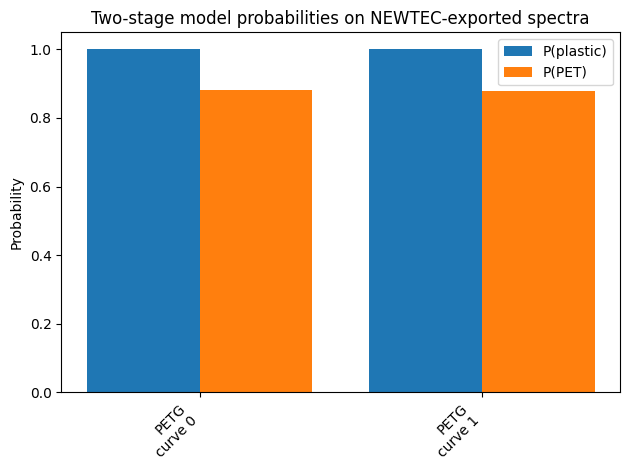

In [3]:
import matplotlib.pyplot as plt

rows = []
for csv_path in csv_files:
    for which in (0, 1):
        try:
            spec, wls = load_camera_csv_smart(str(csv_path), which=which)
            label, p_plastic, p_pet = predict_two_stage(spec, wls)
            rows.append({
                "file": csv_path.stem,
                "curve": which,
                "label": label,
                "p_plastic": p_plastic,
                "p_pet": np.nan if p_pet is None else p_pet
            })
        except Exception as e:
            rows.append({"file": csv_path.stem, "curve": which, "label": "ERROR", "p_plastic": np.nan, "p_pet": np.nan})

df_res = pd.DataFrame(rows)
print(df_res)

# bar plot
plt.figure()
x_labels = [f"{r.file}\ncurve {r.curve}" for r in df_res.itertuples()]
x = np.arange(len(df_res))

plt.bar(x - 0.2, df_res["p_plastic"].fillna(0), width=0.4, label="P(plastic)")
plt.bar(x + 0.2, df_res["p_pet"].fillna(0), width=0.4, label="P(PET)")

plt.xticks(x, x_labels, rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Probability")
plt.title("Two-stage model probabilities on NEWTEC-exported spectra")
plt.legend()
plt.tight_layout()
plt.show()
